IMPORTS

In [20]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

HYPER PARAMETERS

In [21]:
input_size = 14
num_epochs = 10
learning_rate = 0.001
input_length = 720
output_length = 24
batch_size = 64
temperature_column = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


LOAD AND PREPROCESS DATA

In [22]:
df = pd.read_csv(r"jena_climate_2009_2016.csv")
data = df.drop(columns=["Date Time"])
data = data.groupby(data.index // 6).mean()

split_index = int(0.8 * len(data))

train_data = data[:split_index]
val_data = data[split_index:]

scaler = StandardScaler()
train_data = scaler.fit_transform(train_data)
val_data = scaler.transform(val_data)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


JENA DATASET

In [23]:
class JenaDataset(Dataset):

    def __init__(self, data, input_length, output_length, temperature_column):

        self.data = torch.from_numpy(data).float()

        self.input_length = input_length
        self.output_length = output_length
        self.temperature_column = temperature_column

    def __len__(self):

        return len(self.data) - self.input_length - self.output_length + 1

    def __getitem__(self, idx):

        X = self.data[
            idx : idx + self.input_length
        ]

        Y = self.data[
            idx + self.input_length :
            idx + self.input_length + self.output_length,
            self.temperature_column
        ]

        return X, Y

DATASET AND DATALOADERS

In [24]:
train_dataset = JenaDataset(
    train_data,
    input_length,
    output_length,
    temperature_column
)

val_dataset = JenaDataset(
    val_data,
    input_length,
    output_length,
    temperature_column
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

print("Train windows:", len(train_dataset))
print("Validation windows:", len(val_dataset))

Train windows: 55330
Validation windows: 13276


POSITIONAL ENCODING

In [25]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

TRANSFORMER MODEL

In [26]:
class WeatherTransformer(nn.Module):

    def __init__(
        self,
        input_size=14,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        output_size=72
    ):

        super().__init__()

        self.input_projection = nn.Linear(input_size, d_model)

        self.positional_encoding = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=0.2,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):

        x = self.input_projection(x)

        x = self.positional_encoding(x)

        x = self.encoder(x)

        x = x.mean(dim=1)

        output = self.fc(x)

        return output

MODEL INITIALISING

In [27]:
model = WeatherTransformer(
    input_size=14,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    output_size=24
).to(device)

criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=5e-4

)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Using device:", device)
print("Model is on:", next(model.parameters()).device)

Using device: cuda
Model is on: cuda:0


TRAINING LOOP

In [28]:
model.train()

train_losses = []
val_losses = []

best_loss = float("inf")

for epoch in range(num_epochs):

    train_loss = 0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        prediction = model(x_batch)

        loss = criterion(prediction, y_batch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            prediction = model(x_batch)

            loss = criterion(prediction, y_batch)

            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}")


    avg_val_loss = val_loss / len(val_loader)

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), "best_transformer.pth")
        print("Best model saved")


    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))

    scheduler.step(avg_val_loss)

    print("Learning Rate:", optimizer.param_groups[0]["lr"])

    print(
        f"Train Loss : {train_loss/len(train_loader):.5f}\n"
        f"Val Loss   : {val_loss/len(val_loader):.5f}"
    )

    print("\n")



    model.train()

Epoch 1/10
Best model saved
Learning Rate: 0.001
Train Loss : 0.06734
Val Loss   : 0.07080


Epoch 2/10
Best model saved
Learning Rate: 0.001
Train Loss : 0.04021
Val Loss   : 0.06769


Epoch 3/10
Learning Rate: 0.001
Train Loss : 0.03644
Val Loss   : 0.08726


Epoch 4/10
Learning Rate: 0.001
Train Loss : 0.03315
Val Loss   : 0.07994


Epoch 5/10
Learning Rate: 0.0005
Train Loss : 0.03040
Val Loss   : 0.08086


Epoch 6/10
Learning Rate: 0.0005
Train Loss : 0.02576
Val Loss   : 0.07741


Epoch 7/10
Learning Rate: 0.0005
Train Loss : 0.02398
Val Loss   : 0.10281


Epoch 8/10
Learning Rate: 0.00025
Train Loss : 0.02239
Val Loss   : 0.10743


Epoch 9/10
Learning Rate: 0.00025
Train Loss : 0.01997
Val Loss   : 0.12065


Epoch 10/10
Learning Rate: 0.00025
Train Loss : 0.01920
Val Loss   : 0.10977




LOSS CURVE

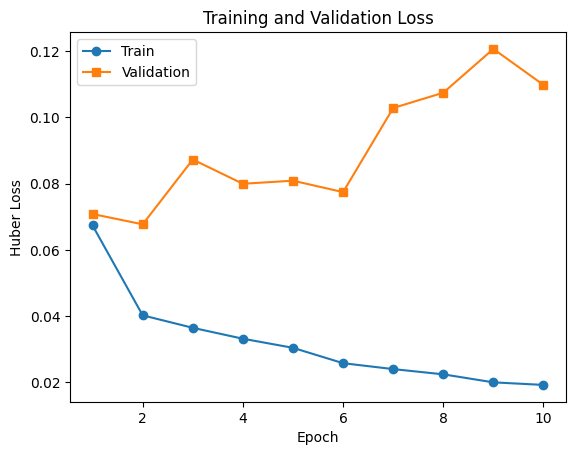

In [29]:
epochs = range(1, num_epochs + 1)

plt.plot(epochs, train_losses, label="Train",marker='o')
plt.plot(epochs, val_losses, label="Validation",marker='s')
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.savefig("Transformer_loss_curve.png", dpi=300)
plt.show()


EVALUATION AND METRICS

In [30]:
model.load_state_dict(
    torch.load(
        "best_transformer.pth",
        map_location=device
    )
)

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for x_batch, y_batch in val_loader:

        x_batch = x_batch.to(device)

        prediction = model(x_batch)

        all_predictions.append(prediction.cpu())
        all_targets.append(y_batch)

prediction = torch.cat(all_predictions).numpy()
target = torch.cat(all_targets).numpy()

prediction = prediction * scaler.scale_[temperature_column] + scaler.mean_[temperature_column]
target = target * scaler.scale_[temperature_column] + scaler.mean_[temperature_column]

mae = mean_absolute_error(target.flatten(), prediction.flatten())
mse = mean_squared_error(target.flatten(), prediction.flatten())
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

with open("metrics.txt","w") as f:
    f.write(f"MAE : {mae}\n")
    f.write(f"MSE : {mse}\n")
    f.write(f"RMSE: {rmse}\n")


MAE : 2.223379937570093
MSE : 10.21394496155107
RMSE: 3.1959263072779183


FORECAST PLOTS

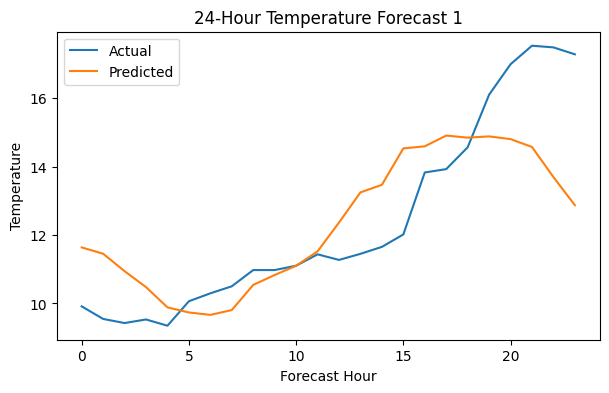

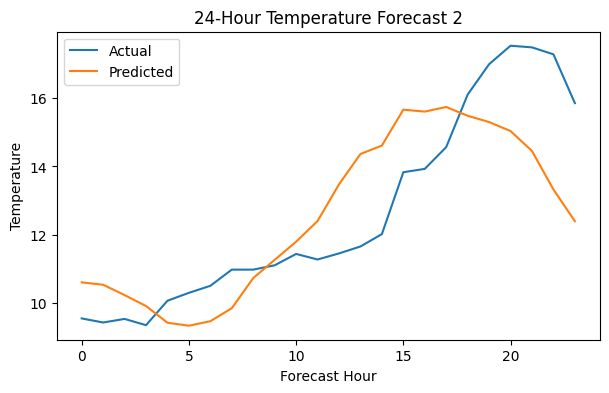

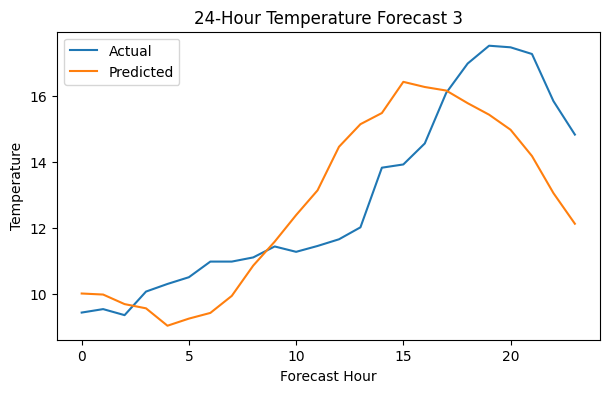

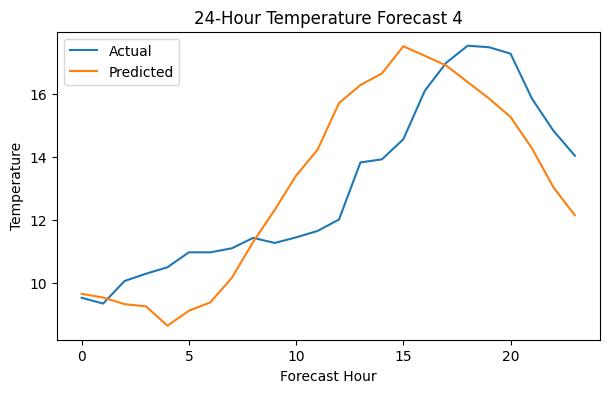

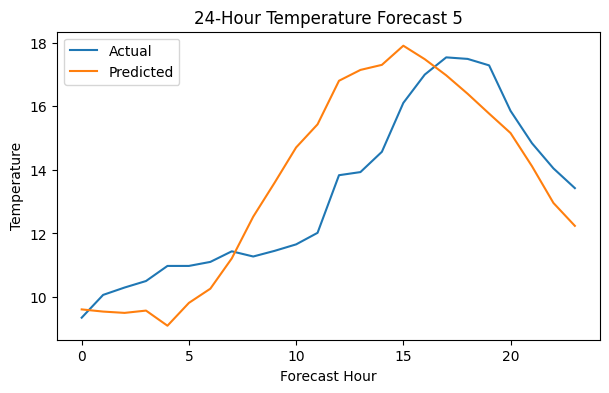

In [31]:
for i in range(5):

    plt.figure(figsize=(7,4))

    plt.plot(target[i], label="Actual")
    plt.plot(prediction[i], label="Predicted")

    plt.title(f"24-Hour Temperature Forecast {i+1}")
    plt.xlabel("Forecast Hour")
    plt.ylabel("Temperature")
    plt.legend()
    plt.savefig(f"transformer_forecast_{i+1}.png", dpi=300)
    plt.show()